---
title: Bayesian HMM GLM
subtitle: Poisson HMM with Covariate-Dependent Emissions
description: Hidden Markov Model with Poisson emissions. Priors and covariates on initial probabilities and transition matrix. On emission is set up a GLM.
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
author: ["Erik De Luca","Tommaso Piscitelli"]
categories: ["Pyro", "Python", "HMM", "Bayesian Models", "Viterbi Algorithm", "GLM"]
date: 2025-07-30
---



# Import and clean data
Import functions and data into the notebook. 
The data is located in the *data* folder, while the functions are in the *python* folder. 
To enhance the readability of the notebook and reduce code redundancy, certain functions are organized into python files and imported as needed.

In [43]:
import sys
import os
from pyprojroot import here

root_dir = str(here())
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# data manipulation
import pandas as pd
import numpy as np
import torch

# modelsp
from pyprojroot import here
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate
from pyro.optim import Adam

# data visualization
import matplotlib.pyplot as plt
import plotnine as pn

# plot settings
from matplotlib import font_manager as fm
from cycler import cycler

# constants and configurations
import config as C

# personal functions
import python.hmm_glm_model as hmm_glm
import python.hmm_glm_viterbi as viterbi
import python.hmm_glm_plots as hmm_pl

# color parameters
plt.rcParams["axes.prop_cycle"] = cycler(color=list(C.STATE_PALETTE.values()))
plt.rcParams['figure.facecolor'] = C.BG_COLOR
fm.fontManager.addfont(here(C.FONT_PATH))

df = pd.read_csv(here("data/recent_donations.csv"))
df

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


The data is pre-processed via *Polars*'s library and transformed into torch elements.

In [3]:
# --- 1. Extract Observations and Lagged Donations ---
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)

# Fill missing values and split into current observations and previous year's donations
obs = df[year_cols].fillna(0).to_numpy(dtype=int)

# --- 2. Fixed Covariates (Initial State Probabilities) ---
df["gender_code"] = (df["gender"] == "F").astype(int)

# Normalize years using mean and standard deviation
birth_year_mean, birth_year_std = df["birth_year"].mean(), df["birth_year"].std()
df["birth_year_norm"] = (df["birth_year"] - birth_year_mean) / birth_year_std

cov_init = df[["birth_year_norm", "gender_code"]].to_numpy()

# --- 3. Dynamic Covariates (Transitions and Emissions) ---
years_num = np.array([int(c[2:]) for c in year_cols])

# Calculate age for each donor across all years
ages = years_num[None, :] - df["birth_year"].to_numpy()[:, None]

# Covid dummy variable
covid_mask = np.isin(years_num, [2020, 2021, 2022]).astype(float)
covid_years = np.tile(covid_mask, (len(df), 1))

# Age binning and one-hot encoding (dropping 18-24 as baseline)
age_bins = np.array([18, 25, 35, 45, 55, 60, 65, 75])
ages_binned = np.clip(np.digitize(ages, age_bins, right=False), 1, len(age_bins) - 1)
ages_onehot = np.eye(len(age_bins) - 1)[ages_binned - 1][:, :, 1:]

# Common components for concatenation
intercept_tile = np.ones((ages_onehot.shape[0], ages_onehot.shape[1], 1))
gender_tile = np.repeat(df["gender_code"].to_numpy()[:, None], T, axis=1)[:, :, None]

# --- 4. Assembly of Covariate Tensors ---
cov_tran = np.concatenate([
    ages_onehot,
    covid_years[:, :, None]
], axis=2)

cov_emission = np.concatenate([
    intercept_tile,
    gender_tile,
    ages_onehot,
    covid_years[:, :, None]
], axis=2)

# --- 5. Convert to Torch Tensors ---
obs_torch = torch.tensor(obs, dtype=torch.long)
cov_init_torch = torch.tensor(cov_init, dtype=torch.float)
cov_tran_torch = torch.tensor(cov_tran, dtype=torch.float)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)

print(f"Observations: {obs_torch.shape}")
print(f"Pi Covariates: {cov_init_torch.shape}")
print(f"Transition Covariates: {cov_tran_torch.shape}")
print(f"Emission Covariates: {cov_emiss_torch.shape}")

Observations: torch.Size([9236, 15])
Pi Covariates: torch.Size([9236, 2])
Transition Covariates: torch.Size([9236, 15, 7])
Emission Covariates: torch.Size([9236, 15, 9])


We are planning to create two models:

- **Development Model**: This model will be used for development purposes, where we will split the observations into training and testing sets. We will evaluate the model's bias and variance to ensure its reliability and performance.

- **Production Model**: This model will be integrated into the dashboard, with the primary goal of achieving the best possible predictions. In this case, more data will enhance the model's predictive power and accuracy. So, we will use the full dataset to train it.

In [4]:
# stratified split 90/10 by gender × age-bin (age at t=0)
N, T = obs_torch.shape
age0 = ages[:, 0]                                          # (N,)
age0_bin = np.digitize(age0, age_bins, right=False)        # 1..7
age0_bin = np.clip(age0_bin, 1, len(age_bins))
labels = np.array([f"{int(g)}-{int(b)}" for g, b in zip(df["gender_code"].to_numpy(), age0_bin)])

rng = np.random.default_rng(42)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# subset train and test
# torch
obs_train_torch = obs_torch[train_idx]
xpi_train_torch = cov_init_torch[train_idx]
xA_train_torch  = cov_tran_torch[train_idx]
xem_train_torch = cov_emiss_torch[train_idx]
# numpy
obs_train = obs[train_idx]
xpi_train = cov_init[train_idx]
xA_train  = cov_tran[train_idx]
xem_train = cov_emission[train_idx]

# torch
obs_test_torch = obs_torch[test_idx]
xpi_test_torch = cov_init_torch[test_idx]
xA_test_torch  = cov_tran_torch[test_idx]
xem_test_torch = cov_emiss_torch[test_idx]
# numpy
obs_test = obs[test_idx]
xpi_test = cov_init[test_idx]
xA_test  = cov_tran[test_idx]
xem_test  = cov_emission[test_idx]


print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("emission (train):", xem_train.shape)
print("emission (test) :", xem_test.shape)

N train = 8308, N test = 928
emission (train): (8308, 15, 9)
emission (test) : (928, 15, 9)


Covariates names, useful for labeling the plots

In [5]:
age_years_levels = ["18-24","25-34","35-44","45-54","55-59","60-64", "+65"] # TODO: #2 improve age bins  
ref_age_level = "18-24"

cov_names_pi = {
    "birth_year_norm": "Birth Year",
    "gender": "Gender",
}

# create column names for ages binned removing the base level
age_dict = {f"{lev}": f"Age: [{lev}]" for lev in age_years_levels if lev != ref_age_level}

cov_names_A = {}
cov_names_A.update(age_dict)
cov_names_A.update({"covid_years": "Covid Years"})

cov_names_em = {
    "intercept": "Intercept",
    "gender": "Gender",
}
cov_names_em.update(age_dict)
cov_names_em["covid_years"] = "Covid Years"

# Model

Let $x^\pi_n \in \mathbb{R}^2$ encode (`birth_year_norm`, `gender_code`), $x^A_{n,t} \in \mathbb{R}^8$ encode transition covariates (seven age-bin dummies and a covid indicator), and $x^{em}_{n,t} \in \mathbb{R}^9$ encode emission covariates (gender, seven age-bin dummies, covid).

- Hidden state $z_{n,t} \in \{0,1,2\}$
- Observed count $y_{n,t} \in \mathbb{N}$

**Priors**
Asymmetric priors are set up to ensure divisibility from on state to other.

- $\pi_{\text{base}} \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_\pi)$

- $A_{\text{base}}[k,\cdot] \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_{A_k})$

**Slope parameters to learn**

- $W_\pi \in \mathbb{R}^{K\times 2}$

- $W_A \in \mathbb{R}^{K\times K \times 8}$

- $\beta_{em} \in \mathbb{R}^{K \times (1+9)}$ (intercept plus 9 slopes for emission GLMs)

**Initial-state distribution**
$$
\Pr(z_{n,0}=k \mid x^\pi_n) =
\mathrm{softmax}_k \big( \log \pi_{\text{base},k} + W_{\pi,k} \cdot x^\pi_n \big)
$$

**Transition distribution**
$$
\Pr(z_{n,t}=j \mid z_{n,t-1}=k, \ x^A_{n,t}) =
\mathrm{softmax}_j \big( \log A_{\text{base},kj} + W_{A,kj} \cdot x^A_{n,t} \big)
$$

**Emission (State-specific Poisson GLM with age bins)**
$$
y_{n,t} \mid z_{n,t}=k \sim \mathrm{Poisson}\Big(
  \exp\Big( X^{em}_{n,t} \mathbf{\beta_{em,k}}
  \Big)
\Big)
$$

**Variational guide**
- Point-mass for $\pi_{\text{base}}$ and $A_{\text{base}}$ (Delta).
- All $W_\pi$, $W_A$, $\beta_{em}$ are deterministic Pyro params.

**Training**
- Loss: `TraceEnum_ELBO(max_plate_nesting=1)`
- Optimizer: `Adam(lr = 2e-2)` the value is set up manually to get the optimum ELBO with a fixed iterations

In [6]:
K      = 3      # Number of latent states
C_pi   = cov_init.shape[1]      # Initial-state covariates (birth_year_norm, gender_code)
C_A    = cov_tran.shape[2]      # Transition covariates (ages_norm, covid_years)
C_em   = cov_emission.shape[2]      # Emission covariates (gender, 7 age dummies, covid)

# alpha_A  = torch.tensor([
#     [6.,1.,1.],
#     [1.,6.,1.],
#     [1.,1.,6.]
# ])
# alpha_pi = torch.ones(K)

# Asymmetric Dirichlet prior
alpha_pi = torch.tensor([5., 2., 1.])
alpha_A  = torch.ones((K, K))


@config_enumerate
def model_hmm_glm(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # Priors for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1))
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # Slope coefficients for initial and transition covariates (learnt)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))
    # GLM emission coefficients (learnt)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em))

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: GLM on covariates x_em[:, 0, :]
        log_mu0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission at time t
            log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
def guide_hmm_glm(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        # torch.ones(K),
        alpha_pi,
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

In [7]:
# cycles = 2000

# pyro.clear_param_store()
# svi = SVI(model_hmm_glm, guide_hmm_glm,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(cycles):
#     loss = svi.step(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch)
#     if step % round(cycles / 15) == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# param_path = here("models/hmm_glm_full.pt")
# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

To improve the notebook exectution we fit the model only the first time and then loaded

In [8]:
W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here("models/hmm_glm_full.pt"))
# beta_em


## Viterbi Algorithm (with covariates and Poisson-GLM emissions)

For each donor $n=1..N$, find the MAP latent path $z_{0:T}^\ast$. This is an extension of the classic Viterbi algorithm, it has been adapted to our model structure.

**Parameterization (plug-in, posterior means)**
- Covariate-dependent initial distribution:
  - Logits for $\pi$: $\ell_\pi(x_\pi) = \log \pi_{\text{base}} + W_\pi x_\pi$
  - $\pi(x_\pi) = \text{softmax}(\ell_\pi(x_\pi))$
- Covariate-dependent transition matrix:
  - Logits for $A$ at time $t$: $\ell_A(x_{A,t})_{k\to j} = \log A_{\text{base}}[k,j] + \langle W_A[k,j,:], x_{A,t} \rangle$
  - $A(x_{A,t})[k,\cdot] = \text{softmax}_j\bigl(\ell_A(x_{A,t})_{k\to j}\bigr)$
- Emissions:
  - Poisson-GLM per state $k$: $\eta_k(t) = \beta_{em,k,0} + x_{\text{em},t}^T \beta_{em,k}$
  - $\lambda_k(t) = \exp\bigl(\eta_k(t)\bigr)$

**Dynamic Programming**
- Initialization ($t=0$):

$$
\delta_0(k)=\log \pi_k(x_\pi)+\log \text{Poisson}(y_0\mid \lambda_k(0)).
$$

- Recursion for $t=1,\dots,T$:

$$
\delta_t(j)=\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr]+\log \text{Poisson}(y_t\mid \lambda_j(t)),
$$

$$
\psi_t(j)=\arg\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr].
$$

- Back-tracking:

$$
z_T^\ast=\arg\max_k \delta_T(k),
$$

$$
z_{t-1}^\ast=\psi_t\bigl(z_t^\ast\bigr)\quad\text{for }t=T,\dots,1.
$$


In [9]:
paths = viterbi.viterbi_paths_glm(
    obs,
    cov_init,    # (N,C_pi)
    cov_tran,    # (N,T,C_A)
    cov_emission,    # (N,T,C_em)
    here("models/hmm_glm_full.pt")
)
switch_rate = (paths[:, 1:] != paths[:, :-1]).any(1).mean()
print(f"switch rate = {switch_rate:.2%}")

switch rate = 79.86%


## Results

- ELBO steadily decreases from 177k to 124k and then plateaus: optimisation has mostly converged.

- Initial-state distribution $\pi$: State 0 dominates (81 %), followed by state 2 (13 %); state 1 is rare (6 %). Most donors start in state 0.

- Transition matrix $A$ 
    -   Strong self-persistence: $P(0 \rightarrow 0)=0.91$, $P(1 \rightarrow 1)\approx 1$, $P(2 \rightarrow 2)=0.95$.    
    -   Cross-state moves are all < 14 %; once a donor is in a state, they tend to stay there.

- Poisson rates 
    - State 0: most of $\beta$ are negatives. The donation number will be low 
    - State 1: the people who belong to state 1 was more propense to donate during the covid, and in th middle ages.
    - State 2: Who donates very frequently and it icreases with the age, but the coid had a bad effect on them

**Interpretation**: the model has discovered three very stable behavioural profiles -non-donors, heavy donors, and light donors- with rare transitions between them.

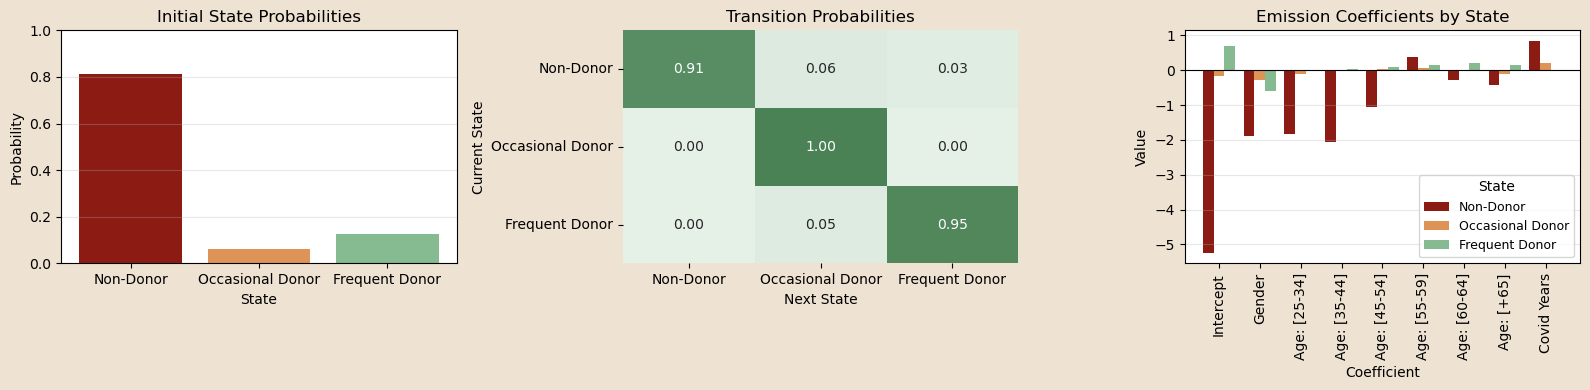

In [10]:
def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# Covariate means
x_mean_pi = cov_init.mean(axis=0)

# Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel() # ravel flats the dimensions from (1,N) to (N)


# Transition matrix building
# time alignament
prev_states = paths[:, :-1] 
x_tran_active = cov_tran[:, 1:, :] 

A_mean_viterbi = np.zeros((K, K))

for k in range(K):
    mask = (prev_states == k) 
    
    if mask.sum() > 0:
        x_mean_k = x_tran_active[mask].mean(axis=0)
    else:
        x_mean_k = np.zeros(C_A)
    
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_k)
    A_mean_viterbi[k] = softmax_row(logits_row[None, :]).ravel()

plots = hmm_pl.plot_hmm_params_with_coeffs(
    transitions=A_mean_viterbi,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=list(C.STATE_NAMES.values()),
    coeff_names=list(cov_names_em.values()),
    show=False    
)

Below the raw values for the number lovers.

In [11]:
print("Initial state probabilities")
print(plots["data"]["init"])

print("\nTransition probabilities")
print(plots["data"]["trans"])

print("\nCoefficients of GLMs")
print(plots["data"]["coeffs"])

Initial state probabilities
              state      prob
0         Non-Donor  0.813352
1  Occasional Donor  0.060081
2    Frequent Donor  0.126567

Transition probabilities
               from                to      prob
0         Non-Donor         Non-Donor  0.909942
1         Non-Donor  Occasional Donor  0.055911
2         Non-Donor    Frequent Donor  0.034147
3  Occasional Donor         Non-Donor  0.002931
4  Occasional Donor  Occasional Donor  0.997051
5  Occasional Donor    Frequent Donor  0.000018
6    Frequent Donor         Non-Donor  0.000083
7    Frequent Donor  Occasional Donor  0.045453
8    Frequent Donor    Frequent Donor  0.954464

Coefficients of GLMs
              state  Intercept    Gender  Age: [25-34]  Age: [35-44]  \
0         Non-Donor  -5.241680 -1.894900     -1.824717     -2.062345   
1  Occasional Donor  -0.169362 -0.292525     -0.092416     -0.014360   
2    Frequent Donor   0.706992 -0.580229      0.003975      0.051169   

   Age: [45-54]  Age: [55-59]  Age:

## Covariates

### Coeficients' Heatmap

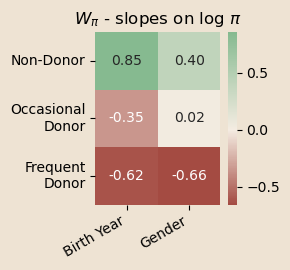

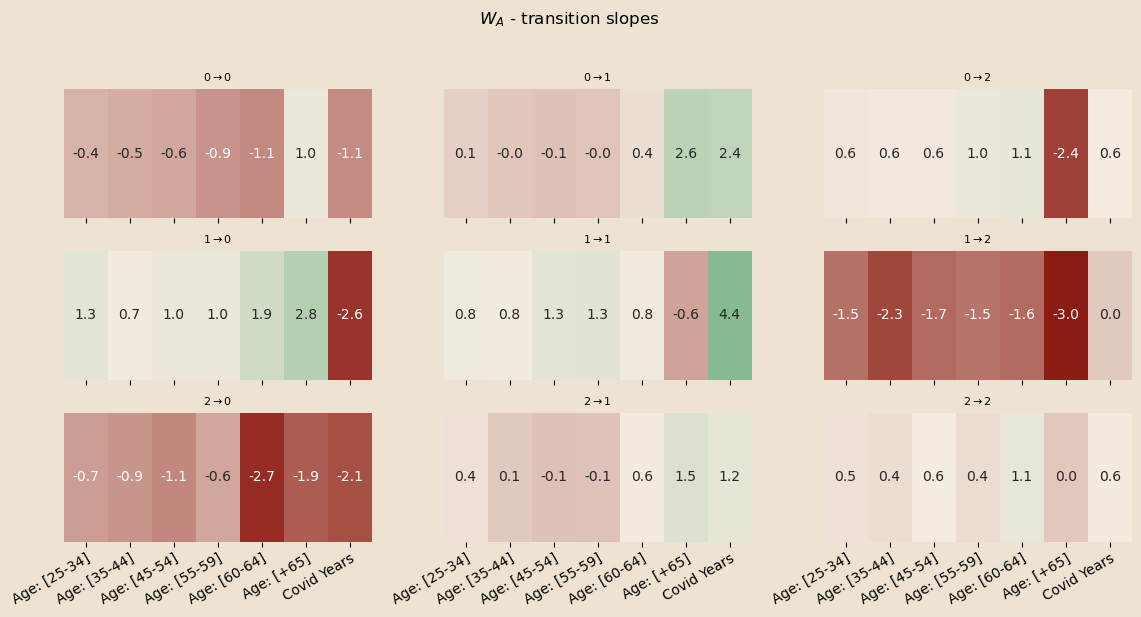

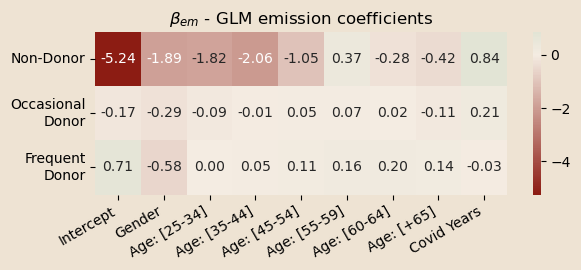

In [12]:
hmm_pl.plot_W_pi_heat(W_pi, cov_names_pi.values())
hmm_pl.plot_W_A_heat(W_A, cov_names_A.values())
hmm_pl.plot_beta_em_heat(beta_em, cov_names_em.values())

## Covariates - Marginal Effects

### Initial probabilities coefficients

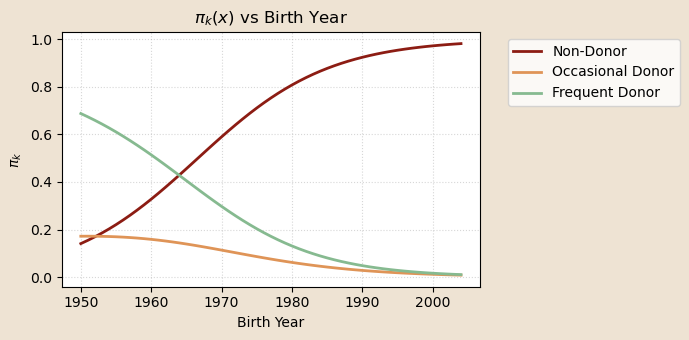

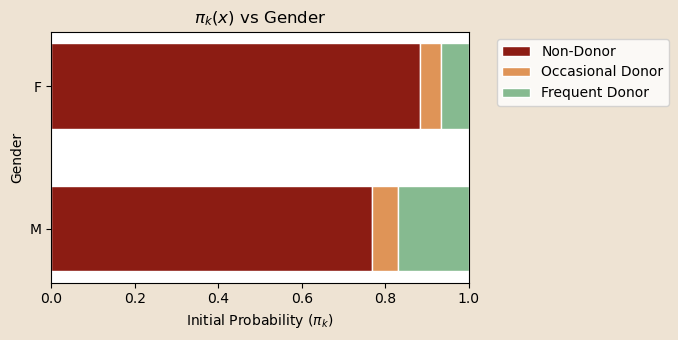

<module 'matplotlib.pyplot' from '/home/erikdeluca/miniforge3/envs/blood-donors/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [13]:
hmm_pl.plot_pi_vs_cov_orig("birth_year_norm", cov_names_pi, W_pi, pi_base, cov_init, birth_year_mean, birth_year_std)
hmm_pl.plot_pi_vs_cov_orig("gender", cov_names_pi, W_pi, pi_base, cov_init, axes_label=["M", "F"])

### Transition matrix coefficients

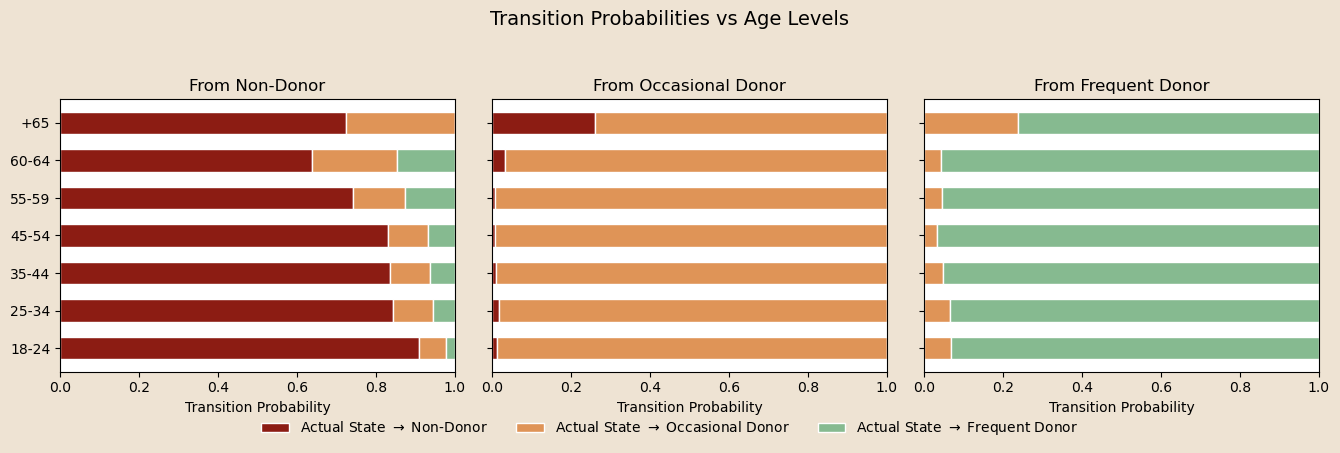

In [14]:
_ = hmm_pl.plot_trans_vs_cov_categorical(
    vars_list=[lev for lev in age_years_levels if lev != ref_age_level],
    cov_names_A=cov_names_A, 
    W_A=W_A, 
    log_A0=np.log(A_base),
    x_A_data=cov_tran,
    axes_label=["18-24"] + [lev for lev in age_years_levels if lev != ref_age_level],
    var_title="Age Levels"
)

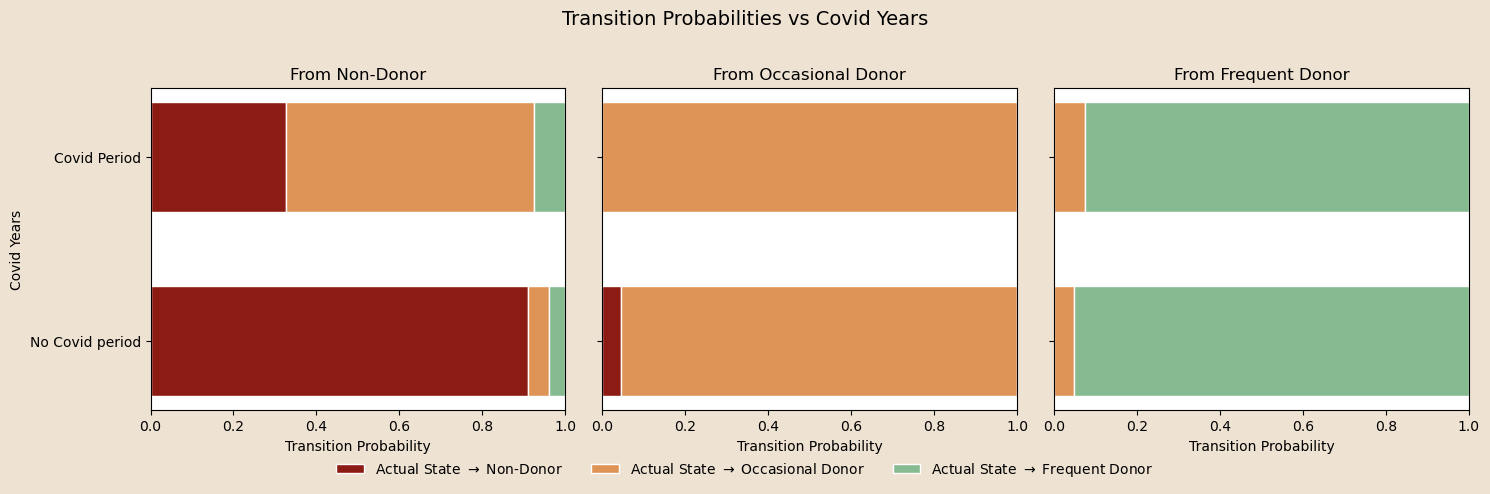

In [15]:
_ = hmm_pl.plot_trans_vs_cov_continuous(
    var="covid_years",
    cov_names_A=cov_names_A, 
    W_A=W_A, 
    log_A0=np.log(A_base),
    x_A_data=cov_tran,
    axes_label=["No Covid period", "Covid Period"]
)

### Emission coefficients

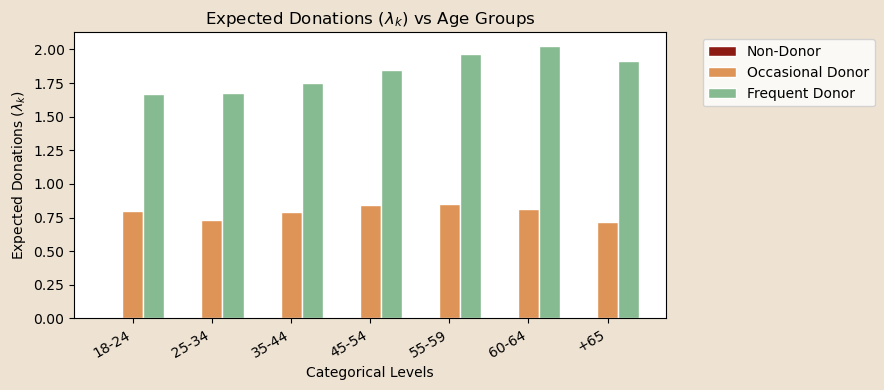

<module 'matplotlib.pyplot' from '/home/erikdeluca/miniforge3/envs/blood-donors/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [16]:
hmm_pl.plot_lambda_em_vs_cov_categorical(
    vars_list=[lev for lev in age_years_levels if lev != ref_age_level],
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=["18-24"] + [lev for lev in age_years_levels if lev != ref_age_level]
)

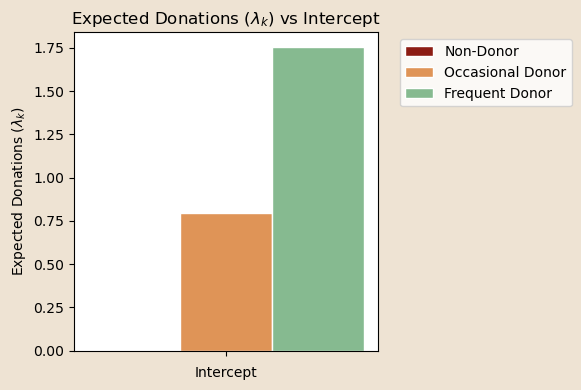

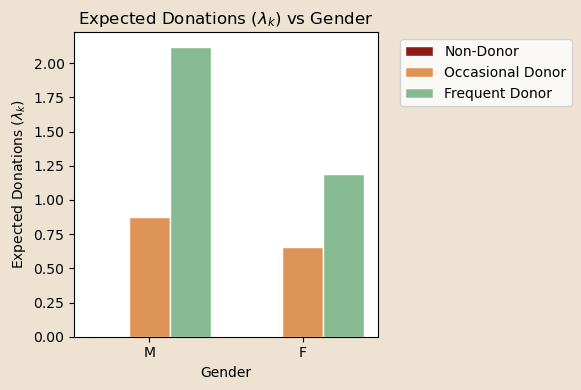

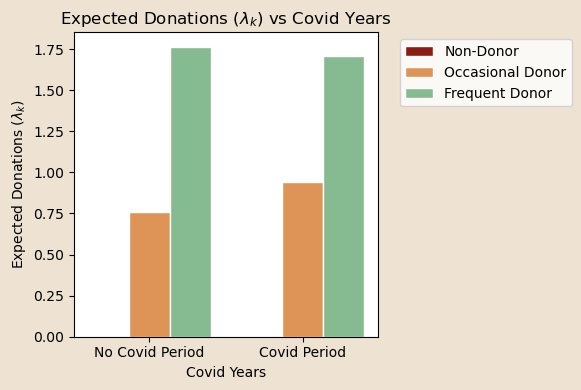

<module 'matplotlib.pyplot' from '/home/erikdeluca/miniforge3/envs/blood-donors/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [17]:
hmm_pl.plot_lambda_em_vs_cov_continuous(
    var="intercept",
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=[""]
)
hmm_pl.plot_lambda_em_vs_cov_continuous(
    var="gender",
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=["M", "F"]
)
hmm_pl.plot_lambda_em_vs_cov_continuous(
    var="covid_years",
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=["No Covid Period", "Covid Period"]
)

## State Occupancy Over Time

### Population View

Looking the plot, it's easy to detect a strong movement from state of "Non-Donor" to state of "Occasional Donor" during the covid years. 

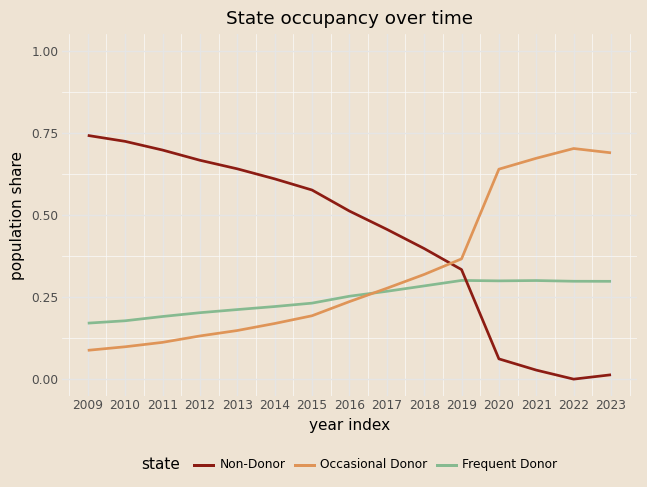

In [18]:
# Counts per state over time
counts = np.stack([(paths == k).sum(axis=0) for k in range(K)], axis=0)
props = counts / np.maximum(counts.sum(axis=0, keepdims=True), 1)  # avoid div-by-zero

rows = []
for k in range(K):
    for t in range(T):
        rows.append({"t": t, "state": C.STATE_NAMES[k], "share": float(props[k, t])})
occupancy = pd.DataFrame(rows)

(
    pn.ggplot(occupancy, pn.aes("t", "share", color="state"))
    + pn.geom_line(size=1.1)
    + pn.scale_color_manual(
        values=list(C.STATE_PALETTE.values()),
        breaks=list(C.STATE_NAMES.values()),
        name="state",
        # labels=list(C.STATE_NAMES.values())
        )
    + pn.scale_x_continuous(breaks=list(range(T)), labels=years_num)
    + pn.scale_y_continuous(limits=(0, 1))
    + pn.labs(x="year index", y="population share", title="State occupancy over time")
    + pn.theme_minimal()
    + pn.theme(
        axis_text_x=pn.element_text(rotation=0),
        legend_position="bottom",
        )
)

### Individual trajectories

Pick a few donors and overlay observations + decoded state for an easy interpretation of the model.

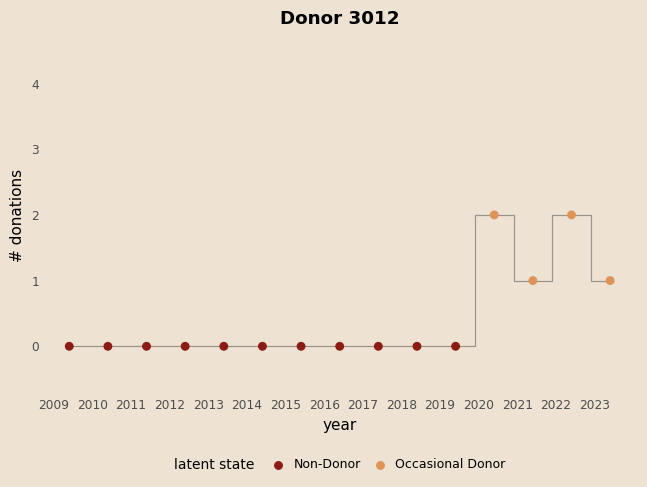

In [19]:
hmm_pl.plot_one_gg(
        idx=3012,
        obs=obs,
        paths=paths,
        years=years_num
    )

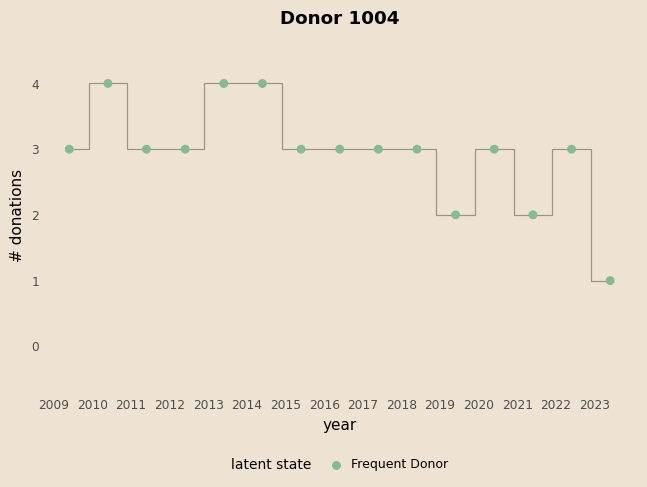

In [20]:
hmm_pl.plot_one_gg(
        idx=1004,
        obs=obs,
        paths=paths,
        years=years_num,
    )

## Predictions

To calculate the predictions, given a new observation, we'll need to do again the data wrangling, like normalize continuous variables, code factor variables, ...
This step is done by the function `prepare_donor_data()`. This function need to know the original mean and standard deviation used for the normalization of the continuous variables, but it's very flexilble in the other aspects. The dimension of the time series is flexible, so the user can just enter a few value, as in the example below.

For the prediction, in the `predict_hmm_donor()`, we calculate in the same cycle the Forward algorithm and Viterbi's algortihm. The first one is used to calculate the $\alpha$ probabilities to belong to each state at the time $T+1$. While, the second one, it give us, for each time $t$, the most probable state to belong at that time.
In this function the prediction is given as the mixture of the different GLM's models at the time $T+1$, weighted by the $\alpha$ probabilities.   

                2018              2019              2020              2021
Donations          0                 1                 0                 2
State      Non-Donor  Occasional Donor  Occasional Donor  Occasional Donor

Prob. to donate (>0): 0.6818

           0       1      2       3     >=4
PMF:  0.3182  0.3497  0.203  0.0855  0.0436


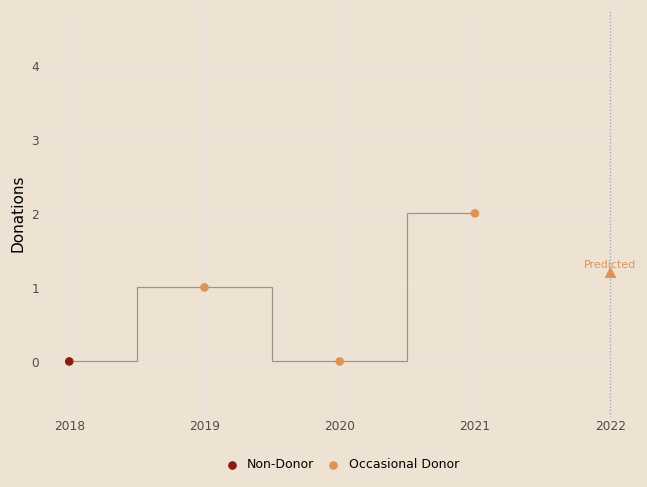

In [21]:
model_params = (W_pi, W_A, pi_base, A_base, beta_em)

obs_donor, x_pi_donor, xA_h, xem_h, xA_n, xem_n, next_yr_donor = hmm_glm.prepare_donor_data_thesis(
    birth_year=1985,
    gender="M",
    history_years=[2018, 2019, 2020, 2021],
    history_counts=[0, 1, 0, 2],
    birth_year_mean=birth_year_mean,
    birth_year_std=birth_year_std
)

results = hmm_glm.predict_hmm_donor(
    obs=obs_donor, 
    x_pi=x_pi_donor, 
    x_A_hist=xA_h, 
    x_em_hist=xem_h, 
    x_A_next=xA_n, 
    x_em_next=xem_n, 
    model_params=model_params, 
    years=[2018, 2019, 2020, 2021]
)

print(results["history_df"])
print(f"\nProb. to donate (>0): {results['prob_donate_next']}")
print(f"\n{pd.DataFrame([results['pmf_next']], index=['PMF:'])}")

hmm_pl.plot_donor_gg(results)

The model is able to catch long periods where the donor wasn't donating and then, it can *reactivate* again at the first donation.

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Donations,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1
State,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor



Prob. to donate (>0): 0.4983

           0       1       2       3     >=4
PMF:  0.5017  0.3333  0.1234  0.0328  0.0088


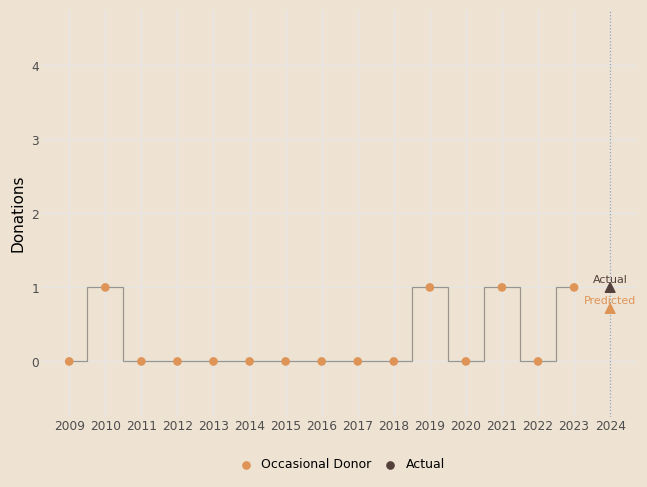

In [22]:
donor_birth_year_obs = 1970
donor_gender_obs = "F"
history_years   = list(range(2009, 2024))
history_counts  = [0,1,0,0,0,0,0,0,0,0,1,0,1,0,1]
next_year = 2024
idx = 4011

obs_donor, x_pi_donor, xA_h, xem_h, xA_n, xem_n, next_yr_donor = hmm_glm.prepare_donor_data_thesis(
    birth_year=donor_birth_year_obs,
    gender=donor_gender_obs,
    history_years=history_years,
    history_counts=history_counts,
    birth_year_mean=birth_year_mean,
    birth_year_std=birth_year_std
)

results = hmm_glm.predict_hmm_donor(
    obs=obs_donor, 
    x_pi=x_pi_donor, 
    x_A_hist=xA_h, 
    x_em_hist=xem_h, 
    x_A_next=xA_n, 
    x_em_next=xem_n, 
    model_params=model_params,
    years=history_years,
    )

display(results["history_df"])
print(f"\nProb. to donate (>0): {results['prob_donate_next']}")
print(f"\n{pd.DataFrame([results['pmf_next']], index=['PMF:'])}")

y_true_next = 1
p = hmm_pl.plot_donor_gg(
    results,
    y_true_next
)
p

A limitation of the model is that it is more propense to predict values smaller then the bigger. 

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Donations,0,0,0,3,4,3,4,3,4,3,2,2,2,3
State,Non-Donor,Non-Donor,Non-Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor



Predizione anno: 2023

Prob. di donare (>0): 0.824

          0       1       2       3     >=4
PMF:  0.176  0.2756  0.2527  0.1644  0.1312


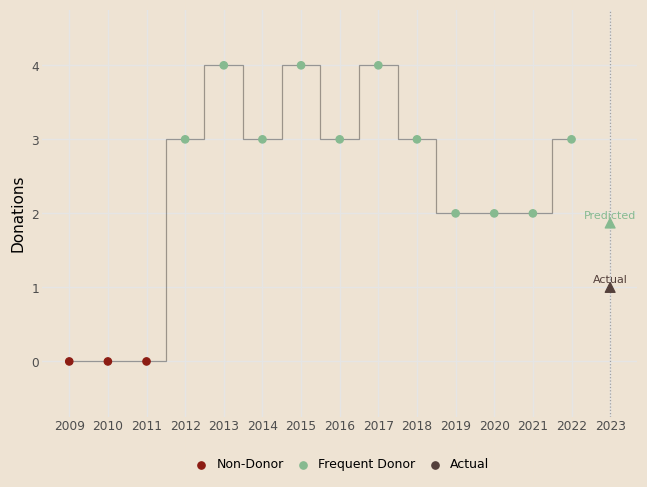

In [23]:
idx = 4011

results = hmm_glm.predict_hmm_donor(
    obs=obs[idx, :-1], 
    x_pi=cov_init[idx, :], 
    x_A_hist=cov_tran[idx, :-1, :], 
    x_em_hist=cov_emission[idx, :-1, :], 
    x_A_next=cov_tran[idx, -1, :], 
    x_em_next=cov_emission[idx, -1, :], 
    model_params=model_params,
    years=years_num,
)

display(results["history_df"])
print(f"\nPredizione anno: {results['next_year']}")
print(f"\nProb. di donare (>0): {results['prob_donate_next']}")
print(f"\n{pd.DataFrame([results['pmf_next']], index=['PMF:'])}")

y_true_next = int(obs[idx, -1])
p = hmm_pl.plot_donor_gg(
    results,
    y_true_next
)
p

# Train and test

Let's split the DB into 2 parts, one will be used for the training and the other one for the testing.
After the training of the model the test part will be used to get the probabilities about the donor and its donation the next year.

In [24]:
# cycles = 2000
# param_path = here("models/hmm_glm_train.pt")

# pyro.clear_param_store()
# svi = SVI(model_hmm_glm, guide_hmm_glm,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(cycles):
#     loss = svi.step(obs_train_torch, xpi_train_torch, xA_train_torch, xem_train_torch)
#     if step % round(cycles / 15) == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

In [25]:
# cycles = 2000
# param_path = here("models/hmm_glm_test.pt")

# pyro.clear_param_store()
# svi = SVI(model_hmm_glm, guide_hmm_glm,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(cycles):
#     loss = svi.step(obs_test_torch, xpi_test_torch, xA_test_torch, xem_test_torch)
#     if step % round(cycles / 15) == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

Load the model and store the parameters

In [26]:
W_pi_train, W_A_train, pi_base_train, A_base_train, beta_em_train = hmm_glm.load_hmm_params(here("models/hmm_glm_train.pt"))
W_pi_test, W_A_test, pi_base_test, A_base_test, beta_em_test = hmm_glm.load_hmm_params(here("models/hmm_glm_test.pt"))

We calculated several metrics on both the training and test sets to evaluate the predictive performance and generalization capabilities of our model.

The mean log-likelihood is slightly higher (less negative) in the test set (-12.388 vs -12.600), and the Negative Log-Likelihood (NLL) shows a similarly consistent trend (0.732 vs 0.751). This demonstrates a complete absence of overfitting, indicating that the latent structure learned by the model generalizes perfectly to unseen sequences.

The Mean Absolute Error (MAE) shows that the model predicts the yearly donation count with an average error of $\approx 0.75$ donations. This is a robust result, indicating that predictions generally deviate by less than one donation from the ground truth. Furthermore, the Root Mean Square Error (RMSE) remains well-controlled ($\approx 1.02$); this tells us that the model does not produce extreme prediction errors (outliers), successfully handling a response variable that assumes discrete values between 0 and 4. 

Finally, we evaluated the Brier score for the binary event of "donating at least once" ($y > 0$). The score is $\approx 0.416$ on the test set. Compared to a random-guess baseline (0.50), this result demonstrates that the fully trained model captures a meaningful predictive edge regarding donor return probability, while correctly preserving the intrinsic, irreducible stochasticity of human behavior in blood donation.

In [27]:
params_train = (W_pi_train, W_A_train, pi_base_train, A_base_train, beta_em_train)
params_test = (W_pi_test, W_A_test, pi_base_test, A_base_test, beta_em_test)

ll_train = hmm_glm.forward_loglik_cov(obs_train, xpi_train, xA_train, xem_train, model_path=here("models/hmm_glm_train.pt"))
ll_test = hmm_glm.forward_loglik_cov(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_train.pt"))

metrics_train = hmm_glm.one_step_ahead_metrics(obs_train, xpi_train, xA_train, xem_train, model_path=here("models/hmm_glm_test.pt"))
metrics_test = hmm_glm.one_step_ahead_metrics(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_test.pt"))


mll_train = ll_train.mean().item()
mll_test = ll_test.mean().item()

metrics_train["Log-Lik"] = mll_train
metrics_test["Log-Lik"] = mll_test

results_df = pd.DataFrame(
    [metrics_train, metrics_test], 
    index=["Train", "Test"]
)

columns_order = ["Log-Lik", "NLL", "MAE", "RMSE", "Brier(y>0)"]
results_df = results_df[columns_order].round(3)

results_df

,Log-Lik,NLL,MAE,RMSE,Brier(y>0)
Train,-13.469,0.914,0.535,0.776,0.134
Test,-13.053,0.879,0.519,0.755,0.135


## Comparison with a GLM

### GLM Poisson in Pyro

Let's define a vanilla GLM to check the results versus our model. 
Even thought is a easy model and it could be defined manually, or with simpler libraries, we decided to define it via Pyro.

- $y \sim \mathrm{Poisson}(\mu)$
- $\log \mu = \beta_0 + \beta_1 \text{birth\_year\_norm} + \beta_2 \text{gender}$

In [28]:
# Poisson GLM with log link
def glm_poisson_model(X, y=None):
    N, C = X.shape
    beta = pyro.param("glm_beta", torch.zeros(C))  # intercept + C slopes
    log_mu = (X @ beta[:].unsqueeze(-1)).squeeze(-1)         # (N,)
    mu = log_mu.exp()
    with pyro.plate("data", N):
        pyro.sample("obs", dist.Poisson(mu), obs=y)

def glm_poisson_guide(X, y=None):
    # Mean-field guide is empty: we use point estimates via pyro.param in the model.
    pass

# Train
def fit_glm_poisson(X, y, steps=3000, lr=1e-2, verbose_every=500, save_path=here("python/glm_poisson_params.pt")):
    X = X.detach()
    y = y.detach().float()
    pyro.clear_param_store()
    svi = SVI(
        lambda X_, y_: glm_poisson_model(X_, y_),
        lambda X_, y_: glm_poisson_guide(X_, y_),
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )
    loss_hist = []
    for s in range(steps):
        loss = svi.step(X, y)
        if verbose_every and s % verbose_every == 0:
            print(f"step {s:4d}: loss={loss:.3f}")
        loss_hist.append(loss)
    pyro.get_param_store().save(save_path)
    return loss_hist

# Predict and metrics
@torch.no_grad()
def glm_poisson_predict(X, beta, return_proba=False):
    X = X.detach()
    log_mu = (X @ beta[:].unsqueeze(-1)).squeeze(-1)
    mu = log_mu.exp()  # expected counts
    if return_proba:
        p_donate = 1.0 - torch.exp(-mu)
        return mu, p_donate
    return mu

@torch.no_grad()
def glm_poisson_evaluate_hmmstyle(X, y, beta):
    """
    Metrics aligned with the HMM printout:
      - pred mean
      - obs mean
      - MSE
      - Accuracy (round)
    """
    X = X.detach()
    y_f = y
    mu = glm_poisson_predict(X, beta, return_proba=False)  # (N,)

    # HMM-style metrics
    pred_mean = mu.mean().item()
    obs_mean  = y_f.mean().item()
    mse = torch.mean((mu - y_f) ** 2).item()
    acc_round = torch.mean((torch.round(mu) == y_f).float()).item()

    return {
        "pred mean": pred_mean,
        "obs mean": obs_mean,
        "MSE": mse,
        "Accuracy (round)": acc_round,
    }


In [29]:
# y_train: last-year counts, X_train: corresponding covariates
y_train = obs_train_torch[:, -1].float()
X_train = xem_train_torch[:, -1, :]

y_test = obs_test_torch[:, -1].float()
X_test = xem_test_torch[:, -1, :]

# loss_hist = fit_glm_poisson(X_train, y_train, steps=2000, lr=1e-1, verbose_every=200)
pyro.get_param_store().load(here("python/glm_poisson_params.pt"))
glm_beta = pyro.param("glm_beta")
y_pred_glm = glm_poisson_predict(X_test, glm_beta)
pred_glm = glm_poisson_predict(X_test, glm_beta, return_proba=True)

### Hold-out Forecast Evaluation

#### HMM multi-state vs GLM

In [30]:
y_test_final = obs_test[:, -1]
results_final = hmm_glm.one_step_ahead(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_train.pt"), pick_one_state=False)
y_pred_hmm_final = results_final["y_expected"][:,-1]

hmm_metrics = hmm_glm.build_hmm_metrics(y_pred_hmm_final, y_test_final)
glm_metrics = hmm_glm.build_hmm_metrics(pred_glm, y_test_final) 

hmm_glm.print_comparison_table(glm_metrics, hmm_metrics)

Metric                        GLM          HMM   Diff (HMM-GLM)   Rel diff %
---------------------------------------------------------------------------
pred mean                    0.79         1.03             0.24       30.39%
obs mean                     0.91         0.91             0.00        0.00%
MSE                        1.0664       0.8320          -0.2344      -21.98%
Accuracy (round)           30.28%       29.85%         -0.43 pp       -1.42%


In [31]:
(np.round(results_final["y_expected"][:,-1], 0) == results_final["y_true"][:,-1]).sum() /  results_final["y_true"].shape[0]

np.float64(0.2984913793103448)

#### HMM one-state vs GLM

In [32]:
y_test_final = obs_test[:, -1]
results_final = hmm_glm.one_step_ahead(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_train.pt"), pick_one_state=True)
y_pred_hmm_final = results_final["y_expected"][:,-1]

hmm_metrics = hmm_glm.build_hmm_metrics(y_pred_hmm_final, y_test_final)
glm_metrics = hmm_glm.build_hmm_metrics(pred_glm, y_test_final) 

hmm_glm.print_comparison_table(glm_metrics, hmm_metrics)

Metric                        GLM          HMM   Diff (HMM-GLM)   Rel diff %
---------------------------------------------------------------------------
pred mean                    0.79         1.02             0.24       30.19%
obs mean                     0.91         0.91             0.00        0.00%
MSE                        1.0664       0.9018          -0.1646      -15.44%
Accuracy (round)           30.28%       29.53%         -0.75 pp       -2.49%


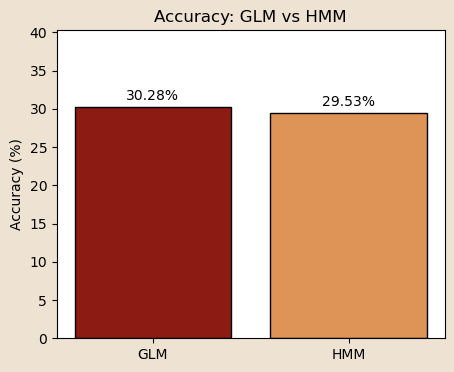

In [33]:
hmm_pl.plot_accuracy(glm_metrics["Accuracy (round)"], hmm_metrics["Accuracy (round)"]) 

In [34]:
y_test_final = np.asarray(obs_test[:, -1]).ravel()

# HMM Multi-State
results_ms = hmm_glm.one_step_ahead(
    obs_test, xpi_test, xA_test, xem_test, 
    model_path=here("models/hmm_glm_train.pt"), 
    pick_one_state=False
)
y_pred_hmm_ms = np.asarray(results_ms["y_expected"][:, -1]).ravel()
error_hmm_ms = y_pred_hmm_ms - y_test_final

# HMM One-State
results_os = hmm_glm.one_step_ahead(
    obs_test, xpi_test, xA_test, xem_test, 
    model_path=here("models/hmm_glm_train.pt"), 
    pick_one_state=True
)
y_pred_hmm_os = np.asarray(results_os["y_expected"][:, -1]).ravel()
error_hmm_os = y_pred_hmm_os - y_test_final

# GLM
error_glm = y_pred_glm - y_test_final

glm_metrics = hmm_glm.build_hmm_metrics(pred_glm, y_test_final) 
hmm_metrics_ms = hmm_glm.build_hmm_metrics(y_pred_hmm_ms, y_test_final)


print("GLM vs HMM (Multi-State Mixture)")
hmm_glm.print_comparison_table(glm_metrics, hmm_metrics_ms)


GLM vs HMM (Multi-State Mixture)
Metric                        GLM          HMM   Diff (HMM-GLM)   Rel diff %
---------------------------------------------------------------------------
pred mean                    0.79         1.03             0.24       30.39%
obs mean                     0.91         0.91             0.00        0.00%
MSE                        1.0664       0.8320          -0.2344      -21.98%
Accuracy (round)           30.28%       29.85%         -0.43 pp       -1.42%


<positron-console-cell-34>:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)


<positron-console-cell-35>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


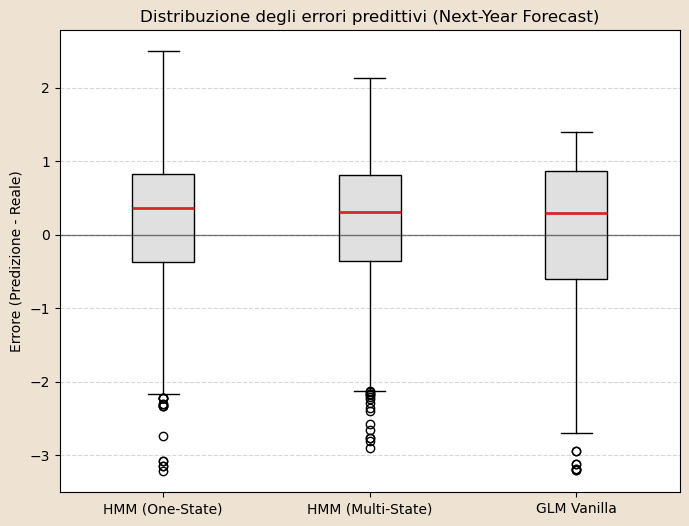

In [35]:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [error_hmm_os, error_hmm_ms, error_glm], 
    labels=["HMM (One-State)", "HMM (Multi-State)", "GLM Vanilla"],
    patch_artist=True, 
    boxprops=dict(facecolor="#e0e0e0", color="black"),
    medianprops=dict(color="#d62728", linewidth=2)
)

# Linea dello zero
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

plt.ylabel("Errore (Predizione - Reale)")
plt.title("Distribuzione degli errori predittivi (Next-Year Forecast)")
plt.grid(True, linestyle="--", alpha=0.5, axis='y')
plt.show()

In [36]:

df_pred = pd.DataFrame({
    "y_pred_hmm_multi_state": y_pred_hmm_ms,
    "y_pred_hmm_one_state": y_pred_hmm_os,
    "y_test": y_test,
    # "y_test": y_test.detach().cpu().numpy().ravel(),
    "y_pred_glm": torch.round(y_pred_glm).int().detach().cpu().numpy().ravel(),
})
df_pred["error_hmm_ms"] = df_pred["y_pred_hmm_multi_state"].round() - df_pred["y_test"]
df_pred["error_hmm_os"] = df_pred["y_pred_hmm_one_state"].round() - df_pred["y_test"]
df_pred["error_glm"] = df_pred["y_pred_glm"].round() - df_pred["y_test"]
df_pred["error_glm_rounded"] = df_pred["error_glm"].astype(int)
df_pred["error_hmm_ms_rounded"] = df_pred["error_hmm_ms"].astype(int)
df_pred["error_hmm_os_rounded"] = df_pred["error_hmm_os"].astype(int)

df_pred.to_csv(here("models/metrics_df_thesis.csv"), index=False)

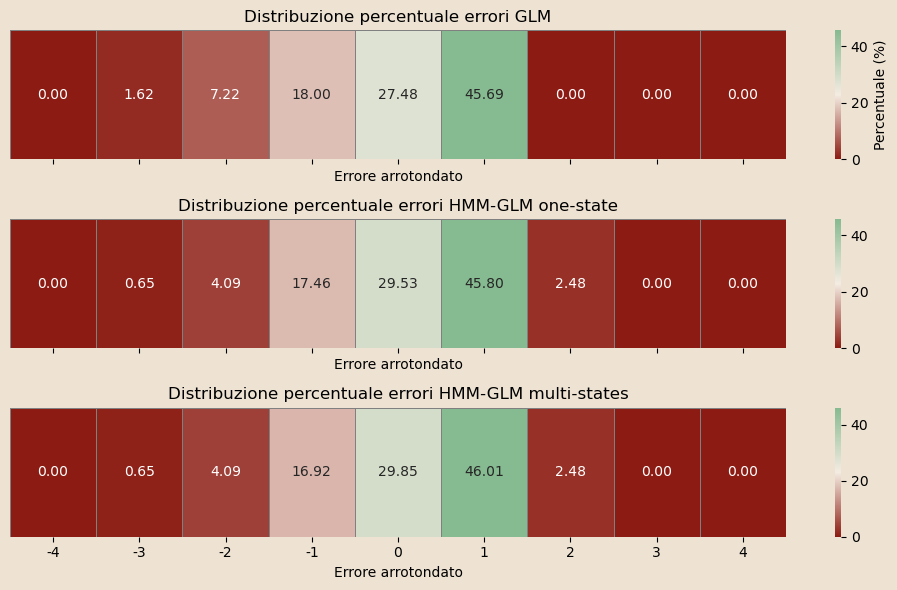

In [37]:
import seaborn as sns

def plot_error_distribution(errors, title, ax):
    full_range = pd.Series(range(-4,5), name="error")
    freq = errors.value_counts(normalize=True).sort_index() * 100
    freq_df = freq.reset_index()
    freq_df.columns = ["error", "percent"]
    freq_df = full_range.to_frame().merge(freq_df, on="error", how="left").fillna(0)
    pivot_df = freq_df.pivot_table(index="error", values="percent")
    sns.heatmap(
        pivot_df.T,
        annot=True,
        fmt=".2f",
        cmap=hmm_pl.COEFF_CMAP,
        cbar_kws={'label': 'Percentuale (%)'} if title=="GLM" else None,
        linewidths=0.5,
        linecolor='gray',
        ax=ax,
        vmin=0, vmax=freq_df["percent"].max()  # uniform color scale
    )
    ax.set_xlabel("Errore arrotondato")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_title(f"Distribuzione percentuale errori {title}")
    ax.set_xticklabels(range(-4,5))

fig, axes = plt.subplots(3,1, figsize=(10,6), sharex=True)
plot_error_distribution(df_pred["error_glm_rounded"], "GLM", axes[0])
plot_error_distribution(df_pred["error_hmm_os_rounded"], "HMM-GLM one-state", axes[1])
plot_error_distribution(df_pred["error_hmm_ms_rounded"], "HMM-GLM multi-states", axes[2])

plt.tight_layout()
plt.show()

### ROC Curve

The plot show how good is the model in the prediction if a donor next year is going to donate or less. The model is not performing very well in this scenario

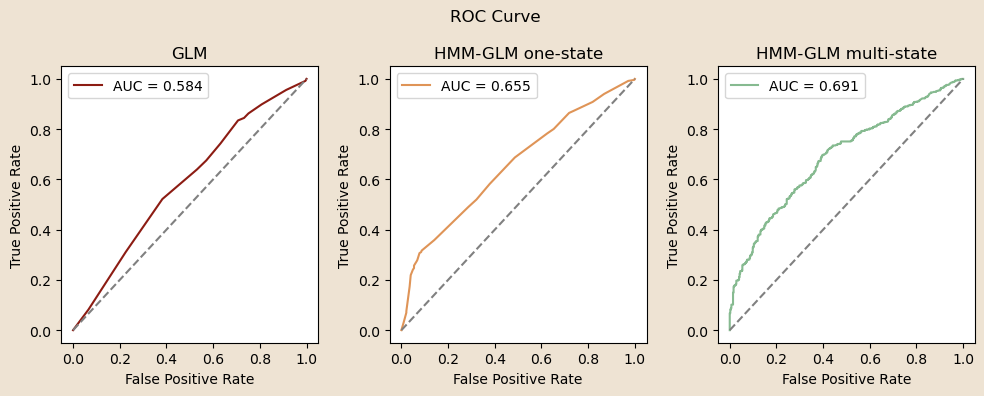

In [38]:
hmm_pl.plot_roc_auc(
    y_test,
    [y_pred_glm, y_pred_hmm_os, y_pred_hmm_ms]
)

# Number of latent states

In [55]:
# functioon for building model and guide with covariates and K states 
def make_hmm_model_and_guide_cov(K):
    @config_enumerate
    def model_k(obs, x_pi, x_A, x_em):
        N, T = obs.shape
        C_pi = x_pi.shape[1]
        C_A  = x_A.shape[2]
        C_em = x_em.shape[2]

        # Priors
        alpha_pi = 0.5 * torch.ones(K)
        alpha_A  = torch.full((K, K), 0.5)
        alpha_A.fill_diagonal_(6.0)
        
        pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))
        A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1))
        
        log_pi_base = pi_base.log()
        log_A_base  = A_base.log()

        # Global parameters
        W_pi  = pyro.param("W_pi", 0.01 * torch.randn(K, C_pi))
        W_A   = pyro.param("W_A",  0.01 * torch.randn(K, K, C_A))
        beta_em = pyro.param("beta_em", 0.01 * torch.randn(K, C_em))
        
        with pyro.plate("seqs", N):
            # Initial state
            logits0 = log_pi_base + (x_pi @ W_pi.T)
            z_prev = pyro.sample("z_0", dist.Categorical(logits=logits0), 
                                 infer={"enumerate": "parallel"})
            
            log_mu_0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
            pyro.sample("y_0", dist.Poisson(log_mu_0.exp()), obs=obs[:, 0])

            # Transitions
            for t in range(1, T):
                x_t = x_A[:, t, :]
                logitsT = log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1)
                z_t = pyro.sample(f"z_{t}", dist.Categorical(logits=logitsT), 
                                  infer={"enumerate": "parallel"})
                
                log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
                pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
                z_prev = z_t
          
    def guide_k(obs, x_pi, x_A, x_em):
        # MAP parameters for pi and A
        pi_q = pyro.param("pi_base_map", torch.ones(K) / K, constraint=dist.constraints.simplex)
        A_init = torch.eye(K) * (K - 1.) + 1.
        A_init = A_init / A_init.sum(-1, keepdim=True)
        A_q = pyro.param("A_base_map", A_init, constraint=dist.constraints.simplex)

        pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
        pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

    return model_k, guide_k

# Reads the variational parameters from the ParamStore and returns point estimates.
def extract_posterior_point_estimates_cov(x_pi, x_A, x_em):
    """
    Reads parameters from ParamStore and computes means based on NumPy covariates.
    """
    def softmax_row(v):
        e = np.exp(v - np.max(v, axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    # Extract learned parameters
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()
    W_A     = pyro.param("W_A").detach().cpu().numpy()
    beta_em = pyro.param("beta_em").detach().cpu().numpy()

    # Covariate means
    x_mean_pi = np.mean(x_pi, axis=0)
    x_mean_A  = np.mean(x_A, axis=(0, 1))
    x_mean_em = np.mean(x_em, axis=(0, 1))

    # Mean initial probs, transitions, and rates
    logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
    pi_mean   = softmax_row(logits_pi[None, :]).ravel()

    K = pi_mean.shape[0]
    A_mean = np.zeros((K, K))
    for k in range(K):
        logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
        A_mean[k] = softmax_row(logits_row[None, :]).ravel()
   
    rates_mean = np.zeros(K)
    for k in range(K):
        rates_mean[k] = np.exp(np.dot(x_mean_em, beta_em[k, :]))

    return pi_mean, A_mean, rates_mean
    
# Uses the learned parameters from the ParamStore to make predictions on test data, compute MSE and Accuracy, and display a plot."
def evaluate_hmm_glm_prediction(obs, x_pi, x_A, x_em):
    """
    Evaluates current ParamStore model using the pure NumPy one_step_ahead function.
    """
    # Predict using model_path=None to read from active Pyro ParamStore
    results = hmm_glm.one_step_ahead(
        obs=obs,
        x_pi=x_pi,
        x_A=x_A,
        x_em=x_em,
        model_path=None, 
        pick_one_state=False
    )
    
    y_pred_hmm = results["y_expected"][:, -1]
    y_test = obs[:, -1]

    mse = np.mean((y_pred_hmm - y_test)**2)
    acc = 100 * np.mean(np.round(y_pred_hmm) == y_test)

    print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
    print(f"MSE: {mse:.4f}")

    return y_pred_hmm, y_test, mse, acc

def log_softmax_logits(logits, dim=-1):
    return logits - torch.logsumexp(logits, dim=dim, keepdim=True)

# Computes the forward algorithm log-likelihood for a covariate-dependent HMM with Poisson emissions using the parameters stored in the Pyro ParamStore.
@torch.no_grad()
def forward_loglik_cov(obs, x_pi, x_A, x_em):
    device = obs.device
    ps = pyro.get_param_store()
    pi_base = ps["pi_base_map"].to(device)
    A_base  = ps["A_base_map"].to(device)
    W_pi    = ps["W_pi"].to(device)
    W_A     = ps["W_A"].to(device)
    beta_em = ps["beta_em"].to(device)

    N, T = obs.shape
    B  = beta_em[:, :]
    log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)       # (N,K)
    log_alpha = log_pi + emis_log[:, 0]

    log_A0 = A_base.log()
    for t in range(1, T):
        x_t = x_A[:, t, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)
        log_alpha = torch.logsumexp(log_alpha.unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    return torch.logsumexp(log_alpha, dim=1)  # (N,)

# Evaluate HMM-GLM models with different numbers of latent states, evaluates them using log-evidence and prediction accuracy
def train_and_evaluate_cov(obs, x_pi, x_A, x_em, K_list, n_steps=500, lr=1e-5, model_dir="models"):
    """
    Trains HMM across K states or loads pre-trained parameters if available.
    """
    os.makedirs(here(model_dir), exist_ok=True)

    log_evidences, final_elbos, accuracies = [], [], []

    # Create PyTorch tensors specifically for SVI
    obs_t  = torch.tensor(obs, dtype=torch.long)
    x_pi_t = torch.tensor(x_pi, dtype=torch.float)
    x_A_t  = torch.tensor(x_A, dtype=torch.float)
    x_em_t = torch.tensor(x_em, dtype=torch.float)

    for K in K_list:
        model_path = os.path.join(here(model_dir), f"hmm_glm_params_K{K}.pt")

        pyro.clear_param_store()

        if os.path.exists(model_path):
            print(f"\n=== Loading pre-trained HMM with K={K} states ===")
            pyro.get_param_store().load(model_path)
            final_elbos.append(np.nan) # ELBO not available when loading
        else:
            print(f"\n=== Training HMM with K={K} states ===")
            model, guide = make_hmm_model_and_guide_cov(K)
            svi = SVI(model, guide, pyro.optim.Adam({"lr": lr}), loss=TraceEnum_ELBO(max_plate_nesting=1))

            losses = []
            for step in range(n_steps):
                loss = svi.step(obs_t, x_pi_t, x_A_t, x_em_t)
                losses.append(loss)
                if step % 50 == 0:
                    print(f"K={K} | step {step:4d}  ELBO = {loss:,.0f}")

            final_elbos.append(-losses[-1])
            
            # Save the trained parameters
            pyro.get_param_store().save(model_path)
            print(f"Model saved to {model_path}")

        # Evaluate predictions (passing original NumPy arrays)
        _, _, _, acc = evaluate_hmm_glm_prediction(obs, x_pi, x_A, x_em)
        accuracies.append(acc)

        # Evaluate log-evidence using our pure NumPy function in hmm_glm_model
        # model_path=None tells load_hmm_params to read the live ParamStore
        log_evidence_val = hmm_glm.forward_loglik_cov(obs, x_pi, x_A, x_em, model_path=None).sum()
        log_evidences.append(log_evidence_val)
        
        print(f"Log-evidence K={K}: {log_evidence_val:.2f}")
        print(f"Accuracy K={K}: {acc:.2f}%")

    # Plots
    plt.figure(figsize=(10, 5))
    plt.plot(K_list, log_evidences, marker='o', label="Log-evidence")
    plt.xlabel("Number of latent states K")
    plt.ylabel("Value")
    plt.title("Model comparison via log-evidence")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar([str(K) for K in K_list], accuracies, color="skyblue")
    plt.xlabel("Number of latent states K")
    plt.ylabel("Accuracy (%)")
    plt.title("Prediction Accuracy by Model (HMM-GLM)")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    y_min = 30
    y_max = max(accuracies) + 2 
    plt.ylim(y_min, y_max)
    plt.yticks(np.arange(y_min, y_max+1, 2))
    plt.show()

    return K_list, log_evidences, final_elbos, accuracies


=== Training HMM with K=2 states ===
K=2 | step    0  ELBO = 177,269
K=2 | step   50  ELBO = 170,878
K=2 | step  100  ELBO = 166,839
K=2 | step  150  ELBO = 163,991
K=2 | step  200  ELBO = 161,449
K=2 | step  250  ELBO = 157,250
K=2 | step  300  ELBO = 150,724
K=2 | step  350  ELBO = 144,813
K=2 | step  400  ELBO = 140,645
K=2 | step  450  ELBO = 137,980
K=2 | step  500  ELBO = 136,213
K=2 | step  550  ELBO = 134,979
K=2 | step  600  ELBO = 134,062
K=2 | step  650  ELBO = 133,339
K=2 | step  700  ELBO = 132,745
K=2 | step  750  ELBO = 132,240
K=2 | step  800  ELBO = 131,800
K=2 | step  850  ELBO = 131,413
K=2 | step  900  ELBO = 131,066
K=2 | step  950  ELBO = 130,755
Model saved to /home/erikdeluca/Blood-Donors/models/hmm_glm_params_K2.pt
HMM(full): pred mean=1.21  obs mean=0.97
MSE: 0.9242
Log-evidence K=2: -130477.12
Accuracy K=2: 31.86%

=== Training HMM with K=3 states ===
K=3 | step    0  ELBO = 177,776
K=3 | step   50  ELBO = 171,193
K=3 | step  100  ELBO = 166,071
K=3 | step  

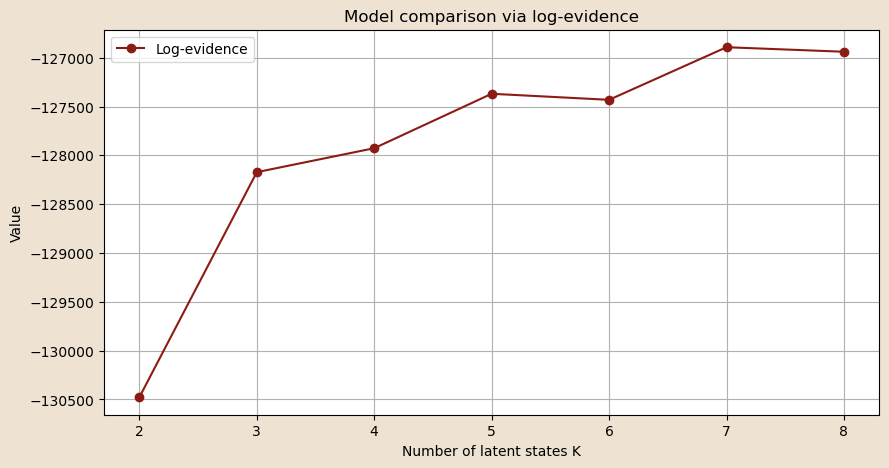

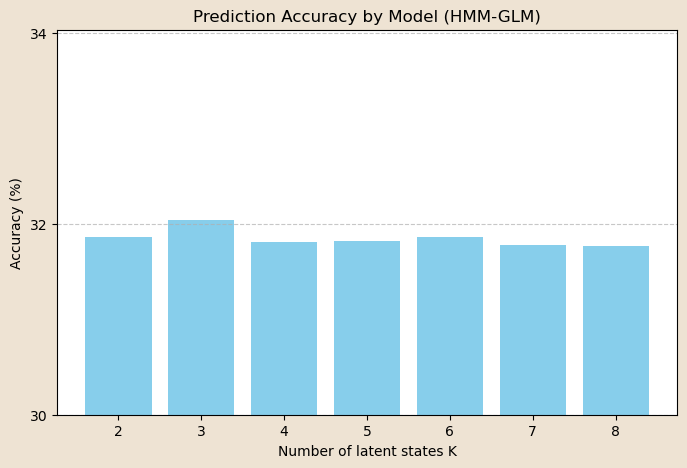

In [58]:
K_list = range(2, 9)
K_list, log_evidences, final_elbos, accuracies = train_and_evaluate_cov(
    obs, 
    cov_init, 
    cov_tran, 
    cov_emission, 
    K_list, 
    n_steps=1_000, 
    lr=2e-3
)

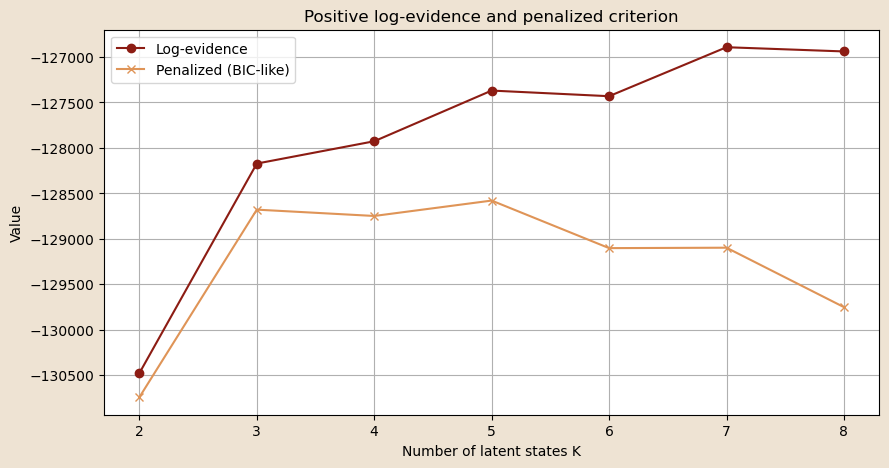

In [ ]:
C_pi = cov_init_torch.shape[1]
C_A  = cov_tran_torch.shape[2]
C_em = cov_emiss_torch.shape[2]


K_list = list(range(2, 9))

# rendiamo valori positivi
#log_evidences_pos = np.abs(log_evidences)

# calcoliamo num_params per ciascun K
num_params_list = []
for K in K_list:
    num_params = K * C_pi + K * K * C_A + K * (C_em + 1) + K + K*K
    num_params_list.append(num_params)
num_params_list = np.array(num_params_list)

# numero di sequenze
N = obs.shape[0]

# criterio penalizzato stile BIC
penalized = log_evidences - 0.5 * num_params_list * np.log(N)

# plot
plt.figure(figsize=(10, 5))
plt.plot(K_list, log_evidences, marker='o', label='Log-evidence')
plt.plot(K_list, penalized, marker='x', label='Penalized (BIC-like)')
plt.xlabel("Number of latent states K")
plt.ylabel("Value")
plt.title("Positive log-evidence and penalized criterion")
plt.grid(True)
plt.legend()
# plt.savefig(here("thesis/img/hmm/bic_plot.png"), dpi=300, bbox_inches="tight", transparent=True)
plt.show()